# 간단한 Perceptron 구현 - 과제

---

## 학습 개요

1. **학습 주제**
  - **PyTorch 기본 연산 및 자동 미분**: Tensor 연산과 autograd 메커니즘을 통한 역전파 자동화
  - **단순 Perceptron 모델 설계**: `nn.Module`을 활용한 신경망 구조 정의 및 파라미터 관리
  - **학습 파이프라인 구성**: DataLoader, optimizer, loss function으로 구성된 학습/검증 루프 구현

2. **학습 목표**
  - PyTorch 텐서 연산과 자동 미분(`autograd`) 메커니즘을 이해하고 활용할 수 있다.
  - `nn.Module`을 활용해 단순 Perceptron 모델을 구현할 수 있다.
  - `DataLoader`, `optimizer`, `loss function`으로 구성된 학습 파이프라인을 이해하고 구현할 수 있다.
  - 이진 분류 문제에서 학습/검증 루프를 작성하고 모델 성능을 평가할 수 있다.
  - 학습 과정에서 손실과 정확도 변화를 시각화하고 해석할 수 있다.

3. **핵심 개념**
  - **`torch.Tensor`**: PyTorch의 기본 데이터 구조로, 다차원 배열 연산과 GPU 가속을 지원한다.
  - **`autograd`**: 텐서 연산을 자동으로 추적하여 역전파 시 기울기를 자동 계산하는 PyTorch 엔진이다.
  - **`nn.Module`**: PyTorch 모델의 기본 클래스로, 레이어와 파라미터를 관리한다.
  - **`DataLoader`**: 배치 단위 데이터 로딩과 셔플링을 지원하는 유틸리티다.
  - **`Binary Cross Entropy`**: 이진 분류에서 사용하는 손실 함수로, 예측 확률과 실제 레이블 간 차이를 측정한다.

4. **선행 지식**
  - Python 기본 문법(변수, 함수, 반복문, 조건문)
  - NumPy 배열 연산 기초
  - 선형 대수 기본 개념 (행렬 연산)
  - (선택) 경사 하강법의 수학적 원리 (없어도 실습 가능하도록 설명 제공)

5. **실습↔과제 연결**
  - 실습에서는 `load_digits` 데이터로 3-layer MLP를 구현했다면, 과제에서는 더 간단한 `make_moons` 2D 데이터로 단순 Perceptron을 구현합니다.
  - 실습에서 학습한 PyTorch 기본 메서드(`nn.Module`, `DataLoader`, `optimizer`, `loss`)를 "학습 파이프라인 관점"으로 다시 정리하고 활용합니다.
  - **조건 변화**: 더 간단한 데이터셋과 더 단순한 모델 구조로 난이도를 낮춥니다.
  - **검증 강화**: 결정 경계 시각화를 추가하여 모델 학습 결과를 직관적으로 확인합니다.

6. **Further Reading**
    - [PyTorch 공식 튜토리얼 - What is torch.nn really?](https://pytorch.org/tutorials/beginner/nn_tutorial.html): PyTorch의 `nn.Module`, `optimizer`, `DataLoader`의 내부 동작 원리를 단계별로 설명한다.
    - [Understanding Backpropagation](https://colah.github.io/posts/2015-08-Backpropagation/): 역전파 알고리즘의 수학적 배경과 계산 그래프를 시각적으로 이해할 수 있다.
    - [Visualizing Neural Networks with the Playground](https://playground.tensorflow.org/): 웹 기반 인터랙티브 도구로 신경망의 학습 과정과 결정 경계를 실시간으로 관찰할 수 있다.

7. **Open-ended Mission**
    - **다양한 활성화 함수 비교**: ReLU, Sigmoid, Tanh 등 다양한 활성화 함수를 적용해 학습 속도와 최종 성능 차이를 비교·분석해보세요.
    - **규제 기법 적용**: L1/L2 정규화, Dropout을 추가하여 과적합 방지 효과를 실험하고, 검증 손실 변화를 관찰해보세요.

## 과제 구성

1. **학습 방향**

- **실습 구성 방식(내용 고정)**
  - 각 단계별로 TODO 영역을 채우며 학습자가 직접 구현

- **Required Package**
  ```
  python==3.11
  numpy>=2.0.0
  matplotlib>=3.8.0
  scikit-learn>=1.4.2
  torch>=2.0.0
  ```

- **Step 요약**
  - **Step 1 (10분)**: PyTorch Tensor와 autograd 복습
  - **Step 2 (15분)**: 데이터셋 준비 및 DataLoader 구성
  - **Step 3 (10분)**: 단순 Perceptron 모델 구현
  - **Step 4 (15분)**: 학습 파이프라인 구현
  - **Step 5 (10분)**: 결과 시각화 및 평가


2. **데이터셋 개요 및 저작권 정보**
  - **데이터셋 명**: scikit-learn `make_moons`
  - **데이터셋 개요**: 두 개의 초승달 모양으로 배치된 2차원 이진 분류 데이터셋으로, 비선형 결정 경계 학습에 적합
  - **사용 목적**: 단순 Perceptron 모델의 학습 및 결정 경계 시각화
  - **저작권/출처**: scikit-learn 라이브러리에서 제공하는 합성 데이터셋으로, BSD 라이선스 하에 자유롭게 사용 가능
  - **주의사항**: 합성 데이터셋이므로 실무 데이터의 복잡성을 반영하지 않음. 학습 목적으로만 사용

3. **문제 설명**
  - **문제 개요**: 이 과제는 **PyTorch 기본 개념 복습과 학습 파이프라인 이해**를 위해 설계되었습니다. 학습자는 **Tensor, autograd, nn.Module, DataLoader, optimizer, loss**를 코드로 확인하고, 최종적으로 **이진 분류 문제에서 모델을 학습시키고 결정 경계를 시각화**할 수 있어야 합니다.

  - **요구사항 요약**
    - **Tensor & autograd**: PyTorch의 자동 미분 메커니즘 이해 및 기울기 계산
    - **데이터 준비**: `make_moons` 데이터셋 생성, 전처리, DataLoader 구성
    - **모델 구현**: `nn.Module`을 상속받아 단순 Perceptron 구현
    - **학습 파이프라인**: Loss, Optimizer 정의 및 학습/검증 루프 작성
    - **결과 분석**: 학습 곡선과 결정 경계 시각화를 통한 모델 성능 평가

4. **학습 문제: Step–TODO 구체 설명**
  - **Step 1 — PyTorch Tensor와 autograd 복습**
    - **TODO 1**: autograd 메커니즘 실습 *(연결 핵심개념: Tensor / autograd / 자동 미분)*
    - **1줄 요약**: 간단한 연산으로 `requires_grad`와 `.backward()`를 통한 자동 미분을 확인한다.

  - **Step 2 — 데이터셋 준비 및 DataLoader 구성**
    - **TODO 2**: 데이터셋 생성 및 전처리 *(연결 핵심개념: make_moons / StandardScaler / train_test_split)*
    - **TODO 3**: PyTorch Tensor 변환 및 DataLoader 생성 *(연결 핵심개념: TensorDataset / DataLoader / 배치 처리)*
    - **1줄 요약**: 데이터를 생성하고 PyTorch 학습에 적합한 형태로 변환한다.

  - **Step 3 — 단순 Perceptron 모델 구현**
    - **TODO 4**: Perceptron 모델 구현 *(연결 핵심개념: nn.Module / nn.Linear / forward)*
    - **1줄 요약**: `nn.Module`을 상속받아 2-layer Perceptron 클래스를 정의한다.

  - **Step 4 — 학습 파이프라인 구현**
    - **TODO 5**: Loss Function과 Optimizer 정의 *(연결 핵심개념: CrossEntropyLoss / Adam / 학습률)*
    - **TODO 6**: 학습 루프 구현 *(연결 핵심개념: train mode / zero_grad / backward / step)*
    - **TODO 7**: 검증 루프 구현 *(연결 핵심개념: eval mode / no_grad / 성능 평가)*
    - **TODO 8**: 전체 학습 실행 *(연결 핵심개념: epoch / 학습-검증 반복)*
    - **1줄 요약**: 학습 파이프라인의 각 구성 요소를 이해하고 전체 학습을 수행한다.

  - **Step 5 — 결과 시각화 및 평가**
    - **TODO 9**: 결정 경계 시각화 함수 구현 *(연결 핵심개념: meshgrid / contourf / 모델 예측)*
    - **1줄 요약**: 모델이 학습한 결정 경계를 시각화하고 성능을 평가한다.

## Import & Install

In [1]:
# 공통 실습 환경 설치 (최초 1회 실행)
!pip install -q \
    "numpy>=2.0.0" \
    "matplotlib>=3.8.0" \
    "scikit-learn>=1.4.2"
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu130


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 재현성을 위한 시드 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)

# Device 설정 (GPU 사용 가능하면 GPU, 아니면 CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Step 1: PyTorch Tensor와 자동 미분(autograd) 복습

### Concept Check: Tensor 기본 연산

PyTorch Tensor는 NumPy의 ndarray와 거의 동일한 방식으로 사용할 수 있습니다. 하지만 GPU 가속과 자동 미분이라는 강력한 기능이 추가되어 있습니다.

**주요 특징**:
1. **GPU 가속**: `.to('cuda')`로 텐서를 GPU로 이동시켜 고속 연산 가능
2. **자동 미분**: `requires_grad=True`로 설정하면 모든 연산이 추적되어 역전파 시 기울기 자동 계산
3. **NumPy 호환**: `.numpy()`와 `torch.from_numpy()`로 상호 변환 가능

In [5]:
# Tensor 생성 예시
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]], requires_grad=True)
print("x:\n", x)
print("x의 shape:", x.shape)
print("x의 dtype:", x.dtype)
print("requires_grad:", x.requires_grad)

x:
 tensor([[1., 2.],
        [3., 4.]], requires_grad=True)
x의 shape: torch.Size([2, 2])
x의 dtype: torch.float32
requires_grad: True


### Concept Check: autograd를 활용한 자동 미분

PyTorch의 `autograd`는 딥러닝 학습의 핵심입니다. 순전파 과정에서 수행한 모든 연산을 자동으로 추적하고, `.backward()` 호출 시 연쇄 법칙(chain rule)을 적용해 각 파라미터의 기울기를 계산합니다.

**학습 파이프라인 관점**:
```python
# 1. 순전파: 모델에 입력을 넣어 예측값 계산
output = model(input)  # 모든 연산이 추적됨

# 2. 손실 계산
loss = loss_fn(output, target)

# 3. 역전파: 손실에서 시작해 모든 파라미터의 기울기 계산
loss.backward()  # autograd가 자동으로 기울기 계산

# 4. 파라미터 업데이트: optimizer가 기울기를 사용해 파라미터 갱신
optimizer.step()
```

### TODO 1: autograd 메커니즘 실습
간단한 연산으로 autograd의 동작을 확인합니다.

**요구사항**:
- 주어진 `x`, `y`에 대해 간단한 선형 연산 `y = w*x + b`를 만족하는 `w`와 `b`를 찾기 위해 손실과 기울기를 계산합니다.
    1. 파라미터 `w`와 `b`를 생성해주세요. 미분을 사용하기 위해서는 `requires_grad=True`로 생성해야하겠죠? 값은 임의로 초기화 해주세요.
    2. 순전파 `y_pred`를 계산해주세요.
    3. 현재 파라미터 `w`와 `b`에 대한 Mean squared error 손실을 계산해 `loss`에 할당해주세요.
    4. `.backward`를 통해 역전파를 수행합니다.

In [6]:
# 입력과 목표값
x = torch.tensor([[3.0]])
y_true = torch.tensor([[8.0]])

# 1. 파라미터 `w`와 `b`를 생성해주세요.
# 미분을 사용하기 위해서는 `requires_grad=True`로 생성해야하겠죠?
# 값은 임의로 초기화 해주세요.
w = torch.tensor([[2.0]], requires_grad=True)
b = torch.tensor([[1.0]], requires_grad=True)

# 2. 순전파 `y_pred`를 계산해주세요.
y_pred = w * x + b

# 3. 현재 파라미터 `w`와 `b`에 대한 Mean squared error 손실을 계산해 `loss`에 할당해주세요.
loss = (y_pred - y_true) ** 2

# 4. `.backward`를 통해 역전파를 수행합니다.
loss.backward()

print(f"예측값: {y_pred.item():.2f}")
print(f"손실: {loss.item():.2f}")
print(f"w의 기울기: {w.grad.item():.2f}")
print(f"b의 기울기: {b.grad.item():.2f}")

예측값: 7.00
손실: 1.00
w의 기울기: -6.00
b의 기울기: -2.00


**해설**:
- `y_pred = w*x + b = 2*3 + 1 = 7`
- `loss = (7 - 8)^2 = 1`
- `∂loss/∂w = 2*(y_pred - y_true)*x = 2*(7-8)*3 = -6`
- `∂loss/∂b = 2*(y_pred - y_true) = 2*(7-8) = -2`

autograd가 자동으로 계산한 기울기가 수식과 일치함을 확인할 수 있습니다.

## Step 2: 데이터셋 준비 및 DataLoader 구성

### Concept Check: DataLoader의 역할

**학습 파이프라인에서 DataLoader의 위치**:
```
Data → DataLoader → Model → Loss → Backward → Optimizer
```

**DataLoader의 주요 기능**:
1. **배치 생성**: 전체 데이터를 `batch_size` 단위로 나누어 제공
2. **셔플링**: `shuffle=True`로 매 epoch마다 데이터 순서를 랜덤하게 섞음 (일반화 성능 향상)
3. **병렬 로딩**: `num_workers`로 멀티프로세싱을 활용해 데이터 로딩 속도 향상

**사용 예시**:
```python
for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
    # x_batch: (batch_size, n_features)
    # y_batch: (batch_size,)
    output = model(x_batch)
    loss = loss_fn(output, y_batch)
    ...
```

### TODO 2: 데이터셋 생성 및 전처리

**요구사항**:
`make_moons`로 생성된 데이터를 훈련과 검증 데이터로 분할한 후 표준화를 수행합니다.
1. 훈련과 검증 데이터를 80%/20%으로 분할해주세요.
   1. 재현성을 위해 난수 고정을 진행해주세요.
   2. 라벨의 stratify를 수행해주세요.
2. `sklearn.preprocessing.StandardScaler`를 통한 표준화를 진행해주세요.

In [7]:
# 데이터 생성
X, y = make_moons(n_samples=1000, noise=0.2, random_state=RANDOM_STATE)

# 1. 훈련과 검증 데이터를 80%/20%으로 분할해주세요.
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# 2. `sklearn.preprocessing.StandardScaler`를 통한 표준화를 진행해주세요.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Valid set: {X_valid.shape}, {y_valid.shape}")

Train set: (800, 2), (800,)
Valid set: (200, 2), (200,)


### 데이터 시각화

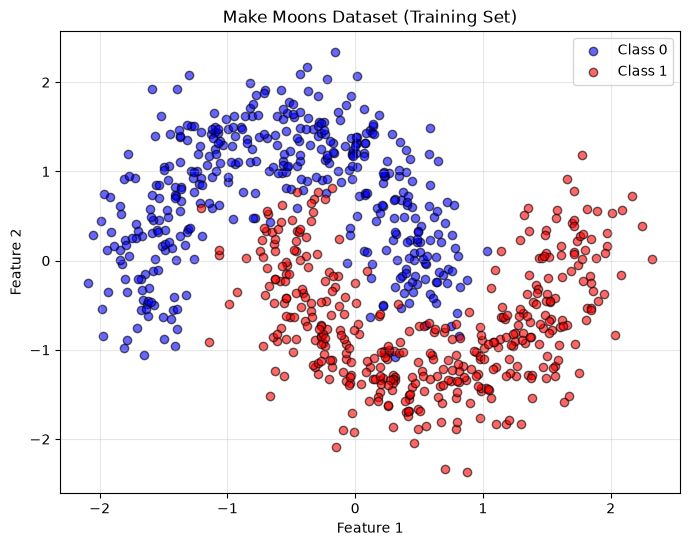

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c='blue', label='Class 0', alpha=0.6, edgecolors='k')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c='red', label='Class 1', alpha=0.6, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Make Moons Dataset (Training Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### TODO 3: PyTorch Tensor 변환 및 DataLoader 생성

**요구사항**:
1. NumPy 배열을 PyTorch Tensor로 변환해주세요.
   1. 이 때 특성(`X_train`, `X_valid`)은 `float` 자료형으로, 라벨은 `long` 자료형으로 변환해주세요.
2. 1에서 변환한 Tensor를 통해 TensorDataset을 생성해주세요.
3. 2에서 생성한 Dataset으로 DataLoader를 생성합니다.
   1. 주어진 BATCH_SIZE에 맞춰 작업해주세요.
   2. 지난 실습에서 수행한대로 훈련 데이터는 `shuffle=True`, 검증데이터는 `shuffle=False`로 수행해주세요.

In [11]:
# 1. NumPy 배열을 PyTorch Tensor로 변환해주세요.
X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).long()
X_valid_t = torch.from_numpy(X_valid).float()
y_valid_t = torch.from_numpy(y_valid).long()

# 2. 1에서 변환한 Tensor를 통해 TensorDataset을 생성해주세요.
train_dataset = TensorDataset(X_train_t, y_train_t)
valid_dataset = TensorDataset(X_valid_t, y_valid_t)

# 3. 2에서 생성한 Dataset으로 DataLoader를 생성합니다.
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Valid batches: {len(valid_loader)}")

# 첫 번째 배치 확인
x_batch, y_batch = next(iter(train_loader))
print(f"\n첫 번째 배치 - X shape: {x_batch.shape}, y shape: {y_batch.shape}")

Train batches: 25
Valid batches: 7

첫 번째 배치 - X shape: torch.Size([32, 2]), y shape: torch.Size([32])


## Step 3: 단순 Perceptron 모델 구현

### Concept Check: nn.Module의 구조

**nn.Module의 기본 패턴**:
```python
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()  # 반드시 호출
        # 레이어 정의
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        # 순전파 로직
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x
```

**학습 파이프라인 관점**:
- `__init__`: 모델의 구조를 정의 (학습할 파라미터 포함)
- `forward`: 입력 데이터를 받아 예측값을 반환 (자동으로 연산 추적)
- `model(x)` 호출 시 내부적으로 `forward(x)`가 실행되며, 동시에 `__call__` 매직 메서드가 호출되어 훅(hook) 등 추가 기능이 동작

### TODO 4: Perceptron 모델 구현

**요구사항**: 2D 입력을 받아 이진 분류를 수행하는 단순 Perceptron을 구현합니다.
1. 주어진 `SimplePerceptron`의 인자에 맞춰 `__init__`에 모델을 구현해주세요
   1. 입력 → 은닉표현1 (hidden_dim) → ReLU → logit (output_dim) 이 되도록 구현해주세요.
   2. 이번에는 `nn.Sequential`을 사용하지 않고 레이어별로 모델의 속성으로 선언해줍니다.
2. `forward`에서 1.1의 로직대로 순전파를 수행해주세요.

In [12]:
class SimplePerceptron(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16, output_dim=2):
        super().__init__()

        # 1. 주어진 `SimplePerceptron`의 인자에 맞춰 `__init__`에 모델을 구현해주세요
        self.fc1 = nn.Linear(input_dim, hidden_dim)  # 입력(2) => 은닉(16)
        self.relu = nn.ReLU()  # 비선형 활성화 함수
        self.fc2 = nn.Linear(hidden_dim, output_dim)  # 은닉(16) -> 출력(2, 클래스 개수)
        
    def forward(self, x):
        # 2. `forward`에서 1.1의 로직대로 순전파를 수행해주세요.
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# 모델 생성 및 테스트
model = SimplePerceptron(input_dim=2, hidden_dim=16, output_dim=2)
print(model)

# 더미 입력으로 테스트
dummy_input = torch.randn(5, 2)
output = model(dummy_input)
print(f"\nInput shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")

SimplePerceptron(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=2, bias=True)
)

Input shape: torch.Size([5, 2])
Output shape: torch.Size([5, 2])


## Step 4: 학습 파이프라인 구현

### Concept Check: Loss Function과 Optimizer

**Loss Function의 역할**:
- 모델의 예측이 얼마나 정확한지 수치로 표현
- 이진 분류: `nn.CrossEntropyLoss()` (내부적으로 Softmax + NLL Loss)
- 학습 파이프라인에서 역전파의 시작점

**Optimizer의 역할**:
- 계산된 기울기를 사용해 파라미터를 업데이트
- `Adam`: 학습률을 자동으로 조절하는 적응형 옵티마이저 (일반적으로 가장 많이 사용)
- `SGD`: 기본 경사하강법

**학습 파이프라인 관점에서의 연결**:
```
Model → Loss → Backward → Optimizer
  ↓       ↓       ↓          ↓
예측값   손실    기울기    파라미터 업데이트
```

### TODO 5: Loss Function과 Optimizer 정의

**요구사항**: 이진 분류에 적합한 Loss Function과 Optimizer를 정의합니다.
1. TODO 4에서 여러분이 직접 만든 모델을 선언하고 가속화기기로 보내줍니다.
2. `torch.nn.CrossEntropyLoss`를 통해 `criterion`을 선언해줍니다.
3. Adam optimizer를 선언해줍니다. 학습률은 주어진 `LR`을 사용해주세요.

In [14]:
# 1. TODO 4에서 여러분이 직접 만든 모델을 선언하고 가속화기기로 보내줍니다.
model = SimplePerceptron(input_dim=2, hidden_dim=16, output_dim=2).to(device)

# 2. `torch.nn.CrossEntropyLoss`를 통해 `criterion`을 선언해줍니다.
criterion = nn.CrossEntropyLoss()

# 3. Adam optimizer를 선언해줍니다. 학습률은 주어진 `LR`을 사용해주세요.
LR = 0.01
optimizer = optim.Adam(model.parameters(), lr=LR)

print(f"Model: {model}")
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")

Model: SimplePerceptron(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=2, bias=True)
)
Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


### TODO 6: 학습 루프 구현

**요구사항**: 한 epoch 동안 학습을 수행하는 함수를 구현합니다.
1. 기울기 초기화를 수행해주세요.
2. 순전파를 통해 `logits`를 얻어주세요
3. 계산한 `logits`와 정답을 통해 손실을 계산해주세요.
4. 3에서 계산한 손실을 통해 역전파를 수행해주세요.
5. 역전파에 따른 파라미터를 업데이트해주세요.

In [16]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    running_loss = 0.0
    correct = 0
    total = 0

    model.train()  # 학습 모드 설정
    for x_batch, y_batch in dataloader:
        # 데이터를 device로 이동
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # 1. 기울기 초기화를 수행해주세요.
        optimizer.zero_grad()

        # 2. 순전파를 통해 `logits`를 얻어주세요
        logits = model(x_batch)

        # 3. 계산한 `logits`와 정답을 통해 손실을 계산해주세요.
        loss = criterion(logits, y_batch)

        # 4. 3에서 계산한 손실을 통해 역전파를 수행해주세요.
        loss.backward()

        # 5. 역전파에 따른 파라미터를 업데이트해주세요.
        optimizer.step()

        # 통계 기록
        running_loss += loss.item() * x_batch.size(0)
        _, predicted = logits.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

### TODO 7: 검증 루프 구현

**요구사항**: 검증 데이터로 모델 성능을 평가하는 `evaluate` 함수를 구현합니다.

1. `model.eval()`과 `torch.no_grad()`를 사용해 평가 모드를 설정합니다.
2. 각 배치에서 입력/라벨을 `device`로 이동합니다.
3. `logits`, `loss`를 계산하고, 정확도 집계를 위해 예측값을 구합니다.
4. 전체 데이터 기준 평균 손실(`epoch_loss`)과 정확도(`epoch_acc`)를 반환합니다.

**입력/출력**: `model`, `dataloader`, `criterion`, `device`를 받아 `(epoch_loss, epoch_acc)`를 반환합니다.


In [18]:
def evaluate(model, dataloader, criterion, device):
    """
    검증/테스트 데이터로 모델을 평가하는 함수

    평가 파이프라인:
    1. model.eval() - 평가 모드 설정 (Dropout 등이 비활성화됨)
    2. torch.no_grad() - 기울기 계산 비활성화 (메모리 절약, 속도 향상)
    3. output = model(input) - 순전파만 수행
    4. loss = criterion(output, target) - 손실 계산 (파라미터 업데이트는 하지 않음)
    """
    model.eval()  # 평가 모드 설정

    running_loss = 0.0
    correct = 0
    total = 0

    # 기울기 계산 비활성화 (메모리 절약)
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            # 데이터를 device로 이동
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # 순전파
            logits = model(x_batch)

            # 손실 계산
            loss = criterion(logits, y_batch)

            # 통계 기록
            running_loss += loss.item() * x_batch.size(0)
            _, predicted = logits.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


여러분들이 구현한 함수가 잘 작동하는지 확인해봅시다.

In [19]:
# 학습 실행
NUM_EPOCHS = 100

train_losses = []
train_accs = []
valid_losses = []
valid_accs = []

for epoch in range(1, NUM_EPOCHS + 1):
    # 학습
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # 검증
    valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)

    # 진행 상황 출력
    if epoch % 10 == 0:
        print(f"Epoch [{epoch:3d}/{NUM_EPOCHS}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:5.2f}% | "
              f"Valid Loss: {valid_loss:.4f} Acc: {valid_acc*100:5.2f}%")

print("\n학습 완료!")

Epoch [ 10/100] Train Loss: 0.1516 Acc: 95.62% | Valid Loss: 0.0988 Acc: 97.50%
Epoch [ 20/100] Train Loss: 0.0983 Acc: 96.50% | Valid Loss: 0.0540 Acc: 99.00%
Epoch [ 30/100] Train Loss: 0.0830 Acc: 96.88% | Valid Loss: 0.0411 Acc: 99.00%
Epoch [ 40/100] Train Loss: 0.0791 Acc: 97.12% | Valid Loss: 0.0348 Acc: 99.00%
Epoch [ 50/100] Train Loss: 0.0747 Acc: 97.12% | Valid Loss: 0.0333 Acc: 99.50%
Epoch [ 60/100] Train Loss: 0.0722 Acc: 97.25% | Valid Loss: 0.0345 Acc: 99.00%
Epoch [ 70/100] Train Loss: 0.0704 Acc: 97.12% | Valid Loss: 0.0338 Acc: 99.00%
Epoch [ 80/100] Train Loss: 0.0687 Acc: 97.50% | Valid Loss: 0.0347 Acc: 98.50%
Epoch [ 90/100] Train Loss: 0.0683 Acc: 97.25% | Valid Loss: 0.0298 Acc: 99.50%
Epoch [100/100] Train Loss: 0.0675 Acc: 97.50% | Valid Loss: 0.0345 Acc: 99.00%

학습 완료!


## Step 5: 결과 시각화 및 평가

### 학습 곡선 시각화

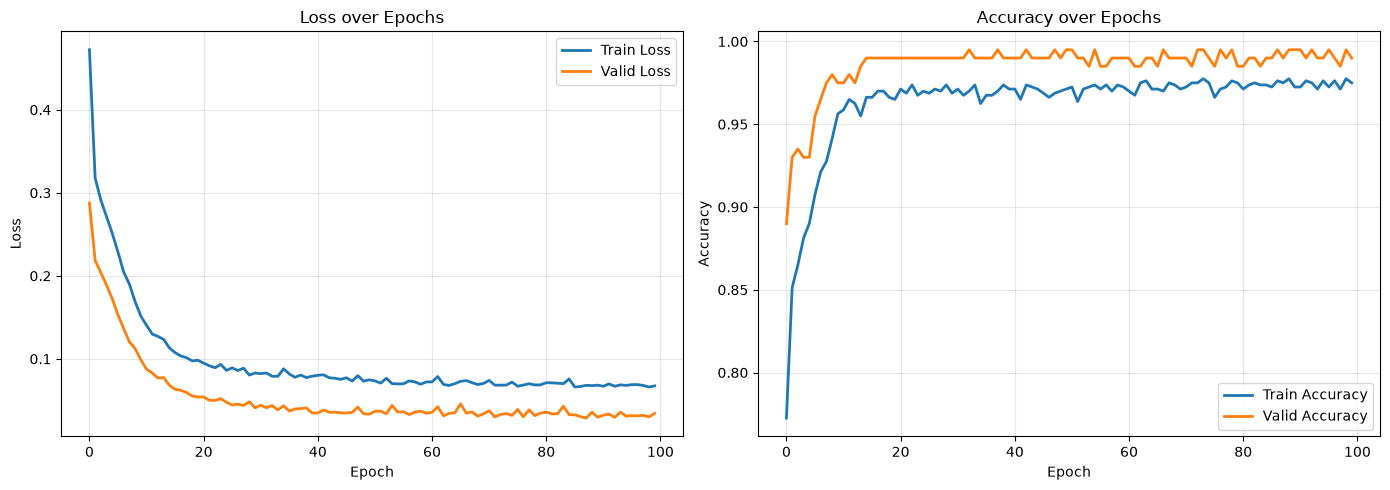

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(valid_losses, label='Valid Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy 그래프
axes[1].plot(train_accs, label='Train Accuracy', linewidth=2)
axes[1].plot(valid_accs, label='Valid Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 학습 곡선 해석 가이드

- **좋은 학습**: Train/Valid Loss가 함께 감소하고, Accuracy가 함께 증가합니다.
- **과적합 신호**: Train Loss는 감소하지만 Valid Loss가 다시 증가합니다.
- **학습 부족 신호**: Loss가 계속 완만히 감소하면 epoch를 조금 더 늘려볼 수 있습니다.


학습이 잘되었는지 확인해볼까요? 아래는 우리의 데이터를 2D 평면에 시각화하는 코드입니다. 실제로 데이터의 라벨과 모델이 생각한 결정경계가 어떻게 다른지 확인해보세요.

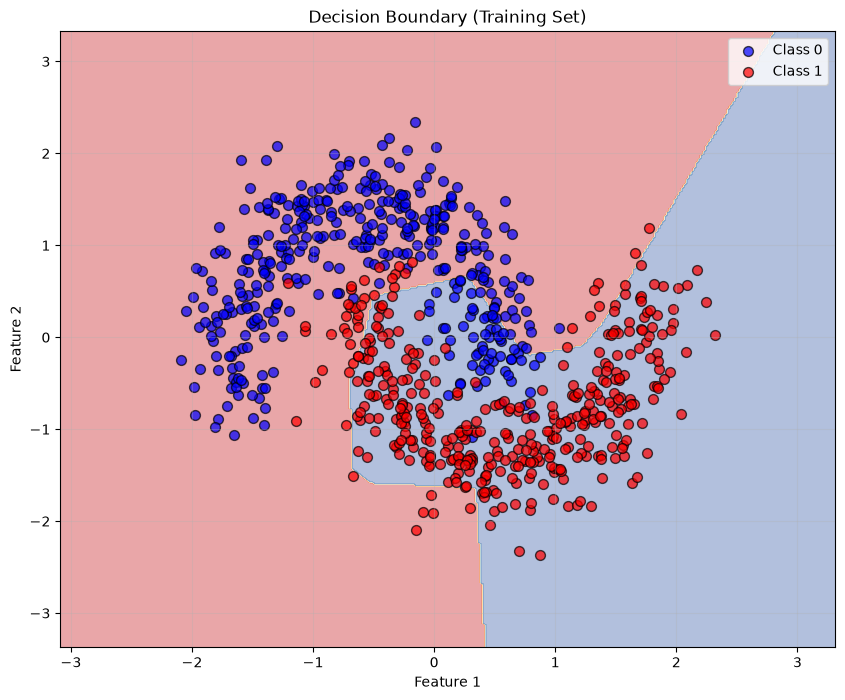

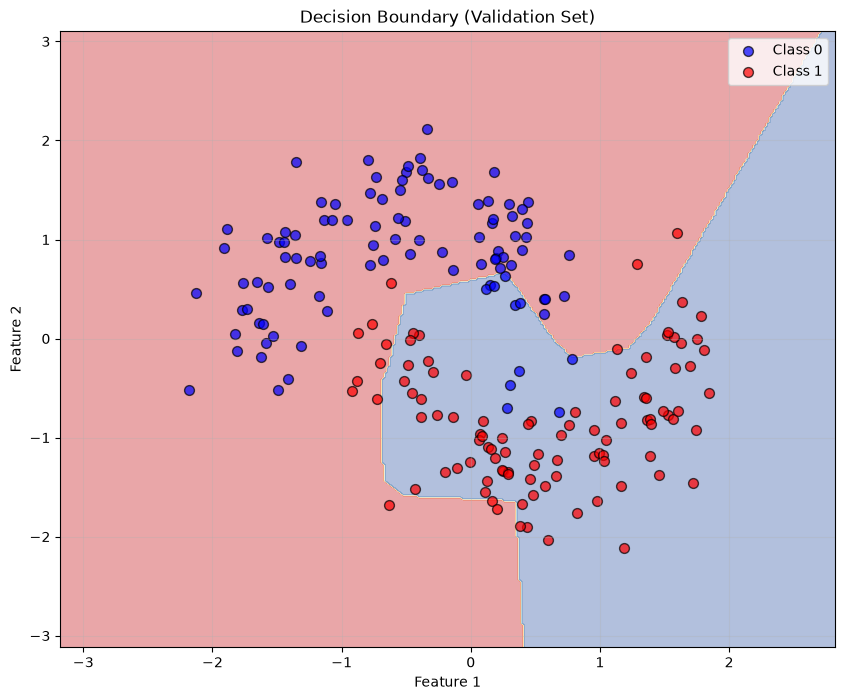

In [21]:
def plot_decision_boundary(model, X, y, scaler, title="Decision Boundary"):
    """
    모델의 결정 경계를 시각화하는 함수
    """
    model.eval()

    # 그리드 생성
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # 그리드 포인트를 모델에 입력
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points_scaled = scaler.transform(grid_points)
    grid_tensor = torch.from_numpy(grid_points_scaled).float().to(device)

    with torch.no_grad():
        outputs = model(grid_tensor)
        _, predictions = outputs.max(1)

    predictions = predictions.cpu().numpy().reshape(xx.shape)

    # 시각화
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, predictions, alpha=0.4, cmap='RdYlBu')
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Class 0',
                edgecolors='k', s=50, alpha=0.7)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Class 1',
                edgecolors='k', s=50, alpha=0.7)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 결정 경계 시각화
plot_decision_boundary(model, X_train, y_train, scaler, "Decision Boundary (Training Set)")
plot_decision_boundary(model, X_valid, y_valid, scaler, "Decision Boundary (Validation Set)")

### 최종 성능 평가

In [23]:
# 최종 검증 성능
final_valid_loss, final_valid_acc = evaluate(model, valid_loader, criterion, device)

print("\n==== 최종 성능 ====")
print(f"Validation Loss: {final_valid_loss:.4f}")
print(f"Validation Accuracy: {final_valid_acc*100:.2f}%")


==== 최종 성능 ====
Validation Loss: 0.0345
Validation Accuracy: 99.00%


### **학습자 자가 체크리스트**

이번 과제를 통해 다음 항목들을 달성했는지 확인해보세요:

- [ ] PyTorch Tensor의 기본 연산과 autograd 메커니즘을 이해했다.
- [ ] `requires_grad=True`의 역할과 `.backward()` 호출 시 기울기가 자동 계산되는 원리를 설명할 수 있다.
- [ ] `nn.Module`을 상속받아 커스텀 모델을 구현할 수 있다.
- [ ] `DataLoader`의 역할과 배치 처리의 이점을 이해했다.
- [ ] 학습 파이프라인(`zero_grad → forward → loss → backward → step`)의 각 단계를 설명할 수 있다.
- [ ] `model.train()`과 `model.eval()`의 차이를 이해하고 적절히 사용할 수 있다.
- [ ] 학습 곡선을 보고 과적합 여부를 판단할 수 있다.
- [ ] 결정 경계 시각화를 통해 모델의 학습 결과를 직관적으로 이해할 수 있다.

### **Content License Agreement**

<font color='red'><b>**WARNING**</b></font> : 본 자료는 삼성청년SW·AI아카데미의 컨텐츠 자산으로, 보안서약서에 의거하여 어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다.